<a href="https://colab.research.google.com/github/Diegochak/clearbank-analise/blob/main/analise_transacoes_financeiras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Transações Financeiras

Este notebook lê transações de um arquivo CSV (`transacoes.csv`), valida cada registro, identifica transações suspeitas (valores acima de um limite) e gera um relatório mensal, exibido na tela e salvo em `relatorio.json`.

## Como utilizar

1. Garanta que o arquivo `transacoes.csv` esteja no ambiente, com as colunas: `id, data, cliente_id, tipo, valor, descricao, categoria`.
2. Execute as células **na ordem**, de cima para baixo (`Shift + Enter`).
3. As células de função apenas definem funções; a célula final (Execução Principal) utiliza todas elas.
4. Ao final, o relatório aparece na saída da última célula e é gravado em `relatorio.json`.

> Observação: execute todas as células de função antes da célula principal, pois ela depende de todas as funções já estarem definidas.

In [12]:
import csv
import json
from datetime import datetime

In [13]:
LIMITE_SUSPEITO = 10000.00

In [14]:
def ler_transacoes(arquivo):
    transacoes = []
    try:
        with open(arquivo, newline='', encoding='utf-8') as f:
            leitor = csv.DictReader(f)
            for linha in leitor:
                transacoes.append(linha)
    except FileNotFoundError:
        print(f"Arquivo nao encontrado: {arquivo}")
    return transacoes

In [15]:
def validar_transacao(transacao):
    """Valida uma transacao. Retorna (True, None) se valida
    ou (False, motivo) se invalida."""
    campos_obrigatorios = ['id', 'data', 'cliente_id', 'tipo', 'valor']
    for campo in campos_obrigatorios:
        if not transacao.get(campo):
            return False, f"Campo obrigatorio ausente ou vazio: {campo}"

    if transacao['tipo'] not in ('credito', 'debito'):
        return False, f"Tipo invalido: {transacao['tipo']}"

    try:
        valor = float(transacao['valor'])
    except ValueError:
        return False, f"Valor nao numerico: {transacao['valor']}"

    if valor <= 0:
        return False, "Valor deve ser maior que zero"

    return True, None

In [16]:

def processar_transacoes(transacoes):
    """Separa transacoes validas de invalidas e identifica
    transacoes suspeitas (valor acima de LIMITE_SUSPEITO)."""
    transacoes_validas = []
    total_invalidas = 0
    transacoes_suspeitas = []

    for transacao in transacoes:
        valida, motivo = validar_transacao(transacao)
        if not valida:
            total_invalidas += 1
            print(f"Transacao invalida (id={transacao.get('id', '?')}): {motivo}")
            continue

        transacao['valor'] = float(transacao['valor'])
        transacoes_validas.append(transacao)

        if transacao['valor'] > LIMITE_SUSPEITO:
            transacoes_suspeitas.append(transacao)

    return transacoes_validas, total_invalidas, transacoes_suspeitas

In [17]:

def gerar_relatorio(transacoes):
    """Gera um resumo mensal com totais de credito, debito e saldo."""
    resumo = {}
    for transacao in transacoes:
        data = transacao['data']  # formato YYYY-MM-DD
        mes = data[:7]            # YYYY-MM
        if mes not in resumo:
            resumo[mes] = {
                'total_credito': 0.0,
                'total_debito': 0.0,
                'saldo': 0.0,
                'quantidade': 0,
            }

        valor = float(transacao['valor'])
        if transacao['tipo'] == 'credito':
            resumo[mes]['total_credito'] += valor
            resumo[mes]['saldo'] += valor
        else:
            resumo[mes]['total_debito'] += valor
            resumo[mes]['saldo'] -= valor
        resumo[mes]['quantidade'] += 1

    return dict(sorted(resumo.items()))

In [18]:
def salvar_json(relatorio, arquivo):
    """Salva o relatorio em um arquivo JSON, tratando erros de escrita."""
    try:
        with open(arquivo, 'w', encoding='utf-8') as f:
            json.dump(relatorio, f, ensure_ascii=False, indent=4)
        print(f"Relatorio salvo em: {arquivo}")
        return True
    except (IOError, OSError) as e:
        print(f"Erro ao salvar o arquivo {arquivo}: {e}")
        return False

In [19]:

def exibir_relatorio(relatorio, total_transacoes_validas, total_transacoes_invalidas, transacoes_suspeitas):
    """Exibe o relatorio de forma legivel no console."""
    print("=" * 50)
    print("RELATORIO DE ANALISE FINANCEIRA")
    print("=" * 50)
    print(f"Transacoes validas:   {total_transacoes_validas}")
    print(f"Transacoes invalidas: {total_transacoes_invalidas}")
    print()

    print("Resumo mensal:")
    for mes, dados in relatorio.items():
        print(f"  {mes}:")
        print(f"    Creditos:   R$ {dados['total_credito']:.2f}")
        print(f"    Debitos:    R$ {dados['total_debito']:.2f}")
        print(f"    Saldo:      R$ {dados['saldo']:.2f}")
        print(f"    Qtde:       {dados['quantidade']}")
    print()

    if transacoes_suspeitas:
        print(f"ALERTA: {len(transacoes_suspeitas)} transacao(oes) suspeita(s) (acima de R$ {LIMITE_SUSPEITO:.2f}):")
        for t in transacoes_suspeitas:
            print(f"  id={t['id']} | {t['data']} | R$ {t['valor']:.2f} | {t.get('descricao', '')}")
    else:
        print("Nenhuma transacao suspeita encontrada.")
    print("=" * 50)

In [20]:
if __name__ == "__main__":
    try:
        transacoes = ler_transacoes('transacoes.csv')
        transacoes_validas, total_invalidas, transacoes_suspeitas = processar_transacoes(transacoes)
        relatorio = gerar_relatorio(transacoes_validas)

        salvar_json({
            "gerado_em": datetime.now().strftime("%Y-%m-%d"),
            "total_transacoes_validas": len(transacoes_validas),
            "total_transacoes_invalidas": total_invalidas,
            "resumo_mensal": relatorio,
        }, 'relatorio.json')

        exibir_relatorio(relatorio, len(transacoes_validas), total_invalidas, transacoes_suspeitas)
    except Exception as e:
        print(f"Erro inesperado ao processar as transacoes: {e}")

Transacao invalida (id=3): Valor nao numerico: abc
Transacao invalida (id=4): Campo obrigatorio ausente ou vazio: cliente_id
Relatorio salvo em: relatorio.json
RELATORIO DE ANALISE FINANCEIRA
Transacoes validas:   18
Transacoes invalidas: 2

Resumo mensal:
  2026-01:
    Creditos:   R$ 3500.00
    Debitos:    R$ 180.50
    Saldo:      R$ 3319.50
    Qtde:       2
  2026-02:
    Creditos:   R$ 15000.00
    Debitos:    R$ 320.00
    Saldo:      R$ 14680.00
    Qtde:       2
  2026-03:
    Creditos:   R$ 8500.00
    Debitos:    R$ 449.90
    Saldo:      R$ 8050.10
    Qtde:       5
  2026-04:
    Creditos:   R$ 20000.00
    Debitos:    R$ 830.00
    Saldo:      R$ 19170.00
    Qtde:       5
  2026-05:
    Creditos:   R$ 23500.00
    Debitos:    R$ 300.00
    Saldo:      R$ 23200.00
    Qtde:       4

ALERTA: 3 transacao(oes) suspeita(s) (acima de R$ 10000.00):
  id=5 | 2026-02-14 | R$ 15000.00 | Transferência suspeita
  id=12 | 2026-04-01 | R$ 12000.00 | Bônus de desempenho
  id=18 | 2026

## Visualização com matplotlib

A célula abaixo gera um **gráfico de barras empilhadas** com o total de crédito e débito por mês, a partir do `relatorio` gerado anteriormente, e salva a imagem como `grafico.png`.

Grafico salvo em: grafico.png


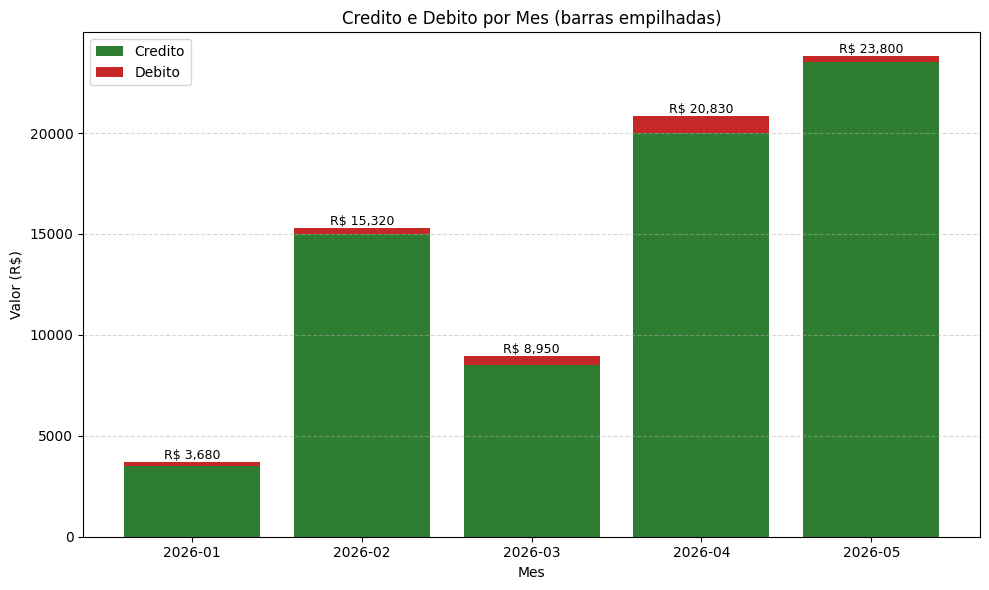

In [21]:
import matplotlib.pyplot as plt

# Dados do relatorio mensal gerado anteriormente
meses = list(relatorio.keys())
creditos = [relatorio[m]['total_credito'] for m in meses]
debitos = [relatorio[m]['total_debito'] for m in meses]

fig, ax = plt.subplots(figsize=(10, 6))

# Barras empilhadas: credito na base, debito empilhado por cima
ax.bar(meses, creditos, label='Credito', color='#2e7d32')
ax.bar(meses, debitos, bottom=creditos, label='Debito', color='#c62828')

ax.set_title('Credito e Debito por Mes (barras empilhadas)')
ax.set_xlabel('Mes')
ax.set_ylabel('Valor (R$)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Rotulos com o valor total (credito + debito) acima de cada barra
for i, mes in enumerate(meses):
    total = creditos[i] + debitos[i]
    ax.text(i, total, f'R$ {total:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('grafico.png', dpi=150)
print('Grafico salvo em: grafico.png')
plt.show()